
== PINN: Re=196, lambda_s=0.77, eta_s=0.0 ===
  X_obs shape: (10, 2)
  z range     : 0.0 → 0.7142857313156128
  U min/max   : -8.610479889359762e-25 → 0.21031250059604645
  V min/max   : -1.0 → 0.0
  W min/max   : -0.0723973885178566 → 0.0
  VKD refs: F'(0)=0.273133, G'(0)=-0.837981, H_inf~H(10.0)=-1.013563
[Uniform GRID] Nr=79, Nz=64, N=5056 (target 5000)

[NOISE] Re=196, layers=4, neu=64, noise=0.0%
Compiling model...
'compile' took 0.000144 s

Training model...

Step      Train loss                                                                                                                  Test loss                                                                                                                   Test metric
0         [2.02e-01, 1.28e+00, 1.65e-01, 3.12e-06, 4.95e-02, 1.70e+00, 3.19e-03, 3.09e-02, 7.71e-02, 2.45e-04, 6.57e-02, 4.94e-01]    [1.96e-01, 1.27e+00, 1.61e-01, 2.64e-06, 4.95e-02, 1.70e+00, 3.19e-03, 3.09e-02, 7.71e-02, 2.45e-04, 6.57e-02, 4.94e-01]    [

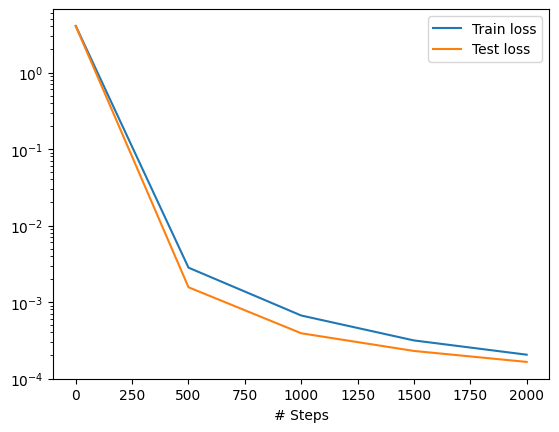

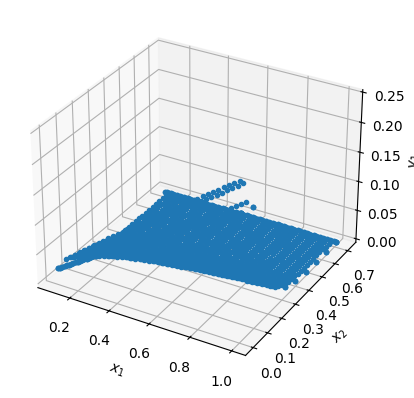

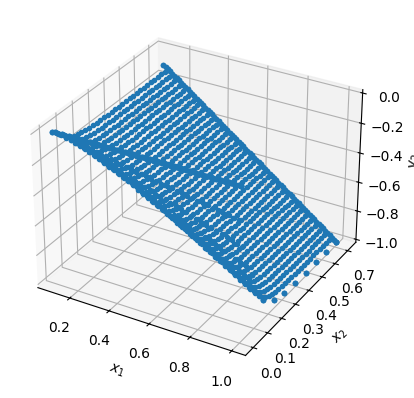

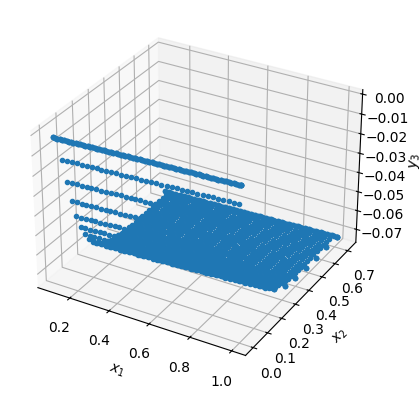

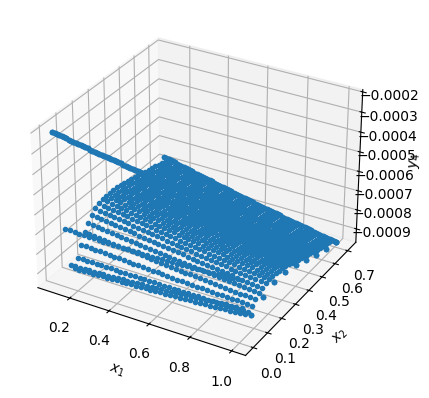

In [5]:
import os
# ⚠ DDE_BACKEND mutlaka deepxde importundan ÖNCE
os.environ["DDE_BACKEND"] = "pytorch"

import numpy as np
import torch
import torch_directml
import deepxde as dde
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt
import csv


# =========================================
# 1) MW-von Kármán nümerik çözücü
# =========================================

def vkd_ode(eta, y):
    """
    MW benzerlik ODE sistemi:
      y[0] = F,  y[1] = F',  y[2] = G,  y[3] = G',  y[4] = H
    """
    f, fp, g, gp, h = y
    return np.vstack([
        fp,
        fp * h + f**2 - g**2,
        gp,
        gp * h + 2 * f * g,
        -2 * f,
    ])


def make_vkd_bc(lambda_slip=0.0, eta_slip=0.0, s_suction=0.0):
    """
    MW sınır şartları (η uzayında):

      F(0) = λ F'(0)          -> f(0) - λ f'(0) = 0
      G(0) - 1 = η G'(0)      -> g(0) - 1 - η g'(0) = 0
      H(0) = -2 s             -> h(0) + 2 s = 0
      F(∞) = 0                -> f(η_max) = 0
      G(∞) = 0                -> g(η_max) = 0
    """
    def vkd_bc(ya, yb):
        f0, fp0, g0, gp0, h0 = ya
        fL, fpL, gL, gpL, hL = yb
        return np.array([
            f0 - lambda_slip * fp0,
            g0 - 1.0 - eta_slip * gp0,
            h0 + 2.0 * s_suction,
            fL,
            gL,
        ])
    return vkd_bc


def solve_vkd(lambda_slip, eta_slip,
              s_suction=0.0, eta_max=10.0, n_eta=400,
              tol=1e-8, max_nodes=200000):
    """
    Verilen (λ, η, s) için benzerlik uzayında MW-von Kármán çözümü.
    """
    eta_mesh = np.linspace(0.0, eta_max, n_eta)
    y_guess = np.zeros((5, eta_mesh.size))
    y_guess[2, :] = 1.0        # G ~ 1
    y_guess[4, :] = -2.0 * s_suction

    bc = make_vkd_bc(lambda_slip=lambda_slip,
                     eta_slip=eta_slip,
                     s_suction=s_suction)

    sol = solve_bvp(vkd_ode, bc, eta_mesh, y_guess, tol=tol, max_nodes=max_nodes)
    if not sol.success:
        raise RuntimeError(
            f"VKD BVP solver did not converge for λ={lambda_slip}, η={eta_slip}: "
            + sol.message
        )
    return sol


def extract_vkd_refs(vk_sol, eta_far: float):
    """
    VKD çözümünden ilgili referansları çeker:
      F'(0), G'(0), H_inf ~ H(eta_far)
    """
    y0 = vk_sol.sol(np.array([0.0], dtype=np.float64))   # shape (5,1)
    yF = vk_sol.sol(np.array([eta_far], dtype=np.float64))

    Fp0 = float(y0[1, 0])       # F'(0)
    Gp0 = float(y0[3, 0])       # G'(0)
    H_inf = float(yF[4, 0])     # H(eta_far) ~ H(∞)

    return Fp0, Gp0, H_inf


def vk_profiles_dense(Re, vk_sol, r_obs=1.0, eta_plot_max=10.0, n_eta_plot=2000):
    """
    VKD çözümünü η üzerinde yoğun (dense) örnekler.
    ÇIKTI: eta_dense, z_dense, U_dense, V_dense, W_dense

    Not: PINN output_transform ile tutarlı olması için:
      U = r*F
      V = r*(G-1)
      W = δ*H   (δ = Re^{-1/2})
    """
    delta_Re = Re ** (-0.5)

    eta_dense = np.linspace(0.0, eta_plot_max, n_eta_plot)
    y_vk = vk_sol.sol(eta_dense)  # (5, n_eta_plot)

    F = y_vk[0, :]
    G = y_vk[2, :]
    H = y_vk[4, :]

    z_dense = (delta_Re * eta_dense).reshape(-1, 1)

    U_dense = (r_obs * F).reshape(-1, 1)
    V_dense = (r_obs * (G - 1.0)).reshape(-1, 1)
    W_dense = (delta_Re * H).reshape(-1, 1)  # fiziksel W

    return (eta_dense.reshape(-1, 1).astype(np.float64),
            z_dense.astype(np.float32),
            U_dense.astype(np.float32),
            V_dense.astype(np.float32),
            W_dense.astype(np.float32))


def select_obs_from_dense(eta_dense, z_dense, U_dense, V_dense, W_dense,
                          r_obs=1.0, n_obs=10):
    """
    Dense profilden n_obs adet noktayı seçer ve PINN PointSetBC formatına sokar.
    """
    N = eta_dense.shape[0]
    idx = np.linspace(0, N - 1, n_obs).astype(int)

    z_obs = z_dense[idx]  # (n_obs,1)
    U_obs = U_dense[idx]
    V_obs = V_dense[idx]
    W_obs = W_dense[idx]

    X_obs = np.hstack([
        (r_obs * np.ones_like(z_obs)),
        z_obs
    ]).astype(np.float32)

    return X_obs, U_obs, V_obs, W_obs, z_obs, idx


# =========================================
# 2) PINN
# =========================================

device = torch_directml.device()
torch.set_default_device(device)
torch.set_default_dtype(torch.float32)



Re_list = [196]

layer_sizes = [4]
neuron_sizes = [64]
lambda_sliP = [0.77]
eta_sliP = [0.0]

# ---------------------------
# PDE
# ---------------------------
def make_pde(Re):
    def pde(x, y):
        r = x[:, 0:1]
        z = x[:, 1:2]

        U = y[:, 0:1]
        V = y[:, 1:2]
        W = y[:, 2:3]
        P = y[:, 3:4]

        U_r = dde.grad.jacobian(y, x, i=0, j=0)
        U_z = dde.grad.jacobian(y, x, i=0, j=1)
        V_r = dde.grad.jacobian(y, x, i=1, j=0)
        V_z = dde.grad.jacobian(y, x, i=1, j=1)
        W_r = dde.grad.jacobian(y, x, i=2, j=0)
        W_z = dde.grad.jacobian(y, x, i=2, j=1)
        P_r = dde.grad.jacobian(y, x, i=3, j=0)
        P_z = dde.grad.jacobian(y, x, i=3, j=1)

        U_rr = dde.grad.jacobian(U_r, x, j=0)
        U_zz = dde.grad.jacobian(U_z, x, j=1)
        V_rr = dde.grad.jacobian(V_r, x, j=0)
        V_zz = dde.grad.jacobian(V_z, x, j=1)
        W_rr = dde.grad.jacobian(W_r, x, j=0)
        W_zz = dde.grad.jacobian(W_z, x, j=1)

        # Rotating-disk PDEs
        eq1 = (1.0 / r) * (U + r * U_r) + W_z
        eq2 = U * U_r + W * U_z - (V + r) ** 2 / r - (1.0 / Re) * (
            U_zz + (1.0 / r) * U_r + U_rr - U / (r ** 2)
        ) + P_r
        eq3 = U * V_r + W * V_z + (U * V) / r + 2.0 * U - (1.0 / Re) * (
            V_zz + (1.0 / r) * V_r + V_rr - V / (r ** 2)
        )
        eq4 = U * W_r + W * W_z + P_z - (1.0 / Re) * (
            (1.0 / r) * W_r + W_rr + W_zz
        )

        return [eq1, eq2, eq3, eq4]

    return pde


# =====================================================
# Gürültü fonksiyonu + relative L2 error
# =====================================================

def add_gaussian_noise(field: np.ndarray,
                       noise_level: float,
                       rng: np.random.Generator) -> np.ndarray:
    """
    field: (N,1) numpy array
    noise_level: 0.01 -> ~%1 genlikte gürültü
    """
    if noise_level <= 0.0:
        return field.copy()

    scale = np.max(np.abs(field))
    if scale == 0.0:
        scale = 1.0

    noise = noise_level * scale * rng.standard_normal(field.shape).astype(np.float32)
    return (field + noise).astype(np.float32)


def relative_L2_error(pred: np.ndarray, ref: np.ndarray) -> float:
    diff = pred - ref
    num = np.sqrt(np.sum(diff**2))
    den = np.sqrt(np.sum(ref**2))
    if den == 0.0:
        return np.nan
    return float(num / den)


# =========================================
# 3) Training cycle
# =========================================
base_dir = "MWDisk_noise_sweep"
os.makedirs(base_dir, exist_ok=True)

noise_levels = [0.0]  # isterse [0.0, 0.01, 0.02, ...]

errors_csv = os.path.join(base_dir, "noise_sweep_errors_MWDISK.csv")
if not os.path.exists(errors_csv):
    with open(errors_csv, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            "Re",
            "n_hidden_layers", "neurons_per_layer",
            "activation", "noise_level",
            "E_U_relL2", "E_V_relL2", "E_W_relL2", "E_comb_relL2",
            "u_prime_r1_z0", "v_prime_r1_z0", "w_r1_zL",
            "Rel_U", "Rel_V", "Rel_W",
            "Fp0_ref", "Gp0_ref", "Hinf_ref",
        ])


def eval_du_dz_dv_dz(net_local, r, z):
    x = torch.tensor([[r, z]], dtype=torch.float32, device=device, requires_grad=True)
    y = net_local(x)  # [U, V, W, P] (output_transform uygulanmış)
    U = y[:, 0:1]
    V = y[:, 1:2]
    dUdx = torch.autograd.grad(U, x, grad_outputs=torch.ones_like(U), retain_graph=True)[0]
    dVdx = torch.autograd.grad(V, x, grad_outputs=torch.ones_like(V), retain_graph=True)[0]
    dU_dz = dUdx[0, 1]
    dV_dz = dVdx[0, 1]
    return dU_dz.detach().cpu().item(), dV_dz.detach().cpu().item()


def build_wall_points(r_vals: np.ndarray) -> np.ndarray:
    r_vals = np.asarray(r_vals, dtype=np.float32).reshape(-1)
    z_wall = np.zeros_like(r_vals, dtype=np.float32)
    return np.column_stack([r_vals, z_wall]).astype(np.float32)


def build_top_points(r_vals: np.ndarray, L: float) -> np.ndarray:
    r_vals = np.asarray(r_vals, dtype=np.float32).reshape(-1)
    z_top = (L * np.ones_like(r_vals, dtype=np.float32))
    return np.column_stack([r_vals, z_top]).astype(np.float32)


for Re in Re_list:
    for eta_s in eta_sliP:
        for lambda_s in lambda_sliP:
            print(f"\n== PINN: Re={Re}, lambda_s={lambda_s}, eta_s={eta_s} ===")
            delta_Re = Re ** (-0.5)
            
            L = 10.0*delta_Re
            r_min = 0.1
            r_max = 1.0
            geom = dde.geometry.Rectangle([r_min, 0.0], [r_max, L])

            pde = make_pde(Re)
        
            # ---------------------------------------------------------
            # 1) Solve the VKD numerical solution in ETA space
            # ---------------------------------------------------------
            eta_far = 10.0
            vk_sol = solve_vkd(
                eta_slip=eta_s,
                lambda_slip=lambda_s,
                s_suction=0.0,
                eta_max=eta_far,
                n_eta=800,
                tol=1e-8,
                max_nodes=200000
            )

            # ---- Retrieve the reference values for this (lambda_s, eta_s) ----
            Fp0_ref, Gp0_ref, Hinf_ref = extract_vkd_refs(vk_sol, eta_far=eta_far)

            # ---------------------------------------------------------
            # 2) First create the dense profile, then select 10 points from the dense profile
            # ---------------------------------------------------------
            eta_dense, z_dense, U_dense, V_dense, W_dense = vk_profiles_dense(
                Re=Re,
                vk_sol=vk_sol,
                r_obs=1.0,
                eta_plot_max=eta_far,
                n_eta_plot=2000
            )

            X_obs, U_obs_ref, V_obs_ref, W_obs_ref, z_obs, idx_obs = select_obs_from_dense(
                eta_dense=eta_dense,
                z_dense=z_dense,
                U_dense=U_dense,
                V_dense=V_dense,
                W_dense=W_dense,
                r_obs=1.0,
                n_obs=10
            )

            print("  X_obs shape:", X_obs.shape)
            print("  z range     :", float(z_obs.min()), "→", float(z_obs.max()))
            print("  U min/max   :", float(U_obs_ref.min()), "→", float(U_obs_ref.max()))
            print("  V min/max   :", float(V_obs_ref.min()), "→", float(V_obs_ref.max()))
            print("  W min/max   :", float(W_obs_ref.min()), "→", float(W_obs_ref.max()))
            print(f"  VKD refs: F'(0)={Fp0_ref:.6f}, G'(0)={Gp0_ref:.6f}, H_inf~H({eta_far})={Hinf_ref:.6f}")

            # ---------------------------------------------------------
            # 3) Numerical solution graph: dense + selected 10 points overlay
            # ---------------------------------------------------------
            fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharex=True)

            axes[0].plot(eta_dense[:, 0], U_dense[:, 0], linewidth=2, label="dense")
            axes[0].plot(eta_dense[idx_obs, 0], U_dense[idx_obs, 0], "o", label="obs(10)")
            axes[0].set_xlabel(r"$\eta$"); axes[0].set_ylabel("U(r=1,η)")
            axes[0].set_title("U (dense + obs)")

            axes[1].plot(eta_dense[:, 0], V_dense[:, 0], linewidth=2)
            axes[1].plot(eta_dense[idx_obs, 0], V_dense[idx_obs, 0], "o")
            axes[1].set_xlabel(r"$\eta$"); axes[1].set_ylabel("V(r=1,η)")
            axes[1].set_title("V (dense + obs)")

            axes[2].plot(eta_dense[:, 0], W_dense[:, 0], linewidth=2)
            axes[2].plot(eta_dense[idx_obs, 0], W_dense[idx_obs, 0], "o")
            axes[2].set_xlabel(r"$\eta$"); axes[2].set_ylabel("W(r=1,η)")
            axes[2].set_title("W (dense + obs)")

            plt.tight_layout()
            fig_dir = os.path.join(base_dir, "figs_obs")
            os.makedirs(fig_dir, exist_ok=True)
            fig.savefig(os.path.join(fig_dir, f"vk_dense_and_obs_eta_Re{int(Re)}_lam{lambda_s}_eta{eta_s}.png"), dpi=200)
            plt.close(fig)

            # =====================================================
            # Uniform GRID anchors
            # =====================================================
            target_N = 5000

            r_span = float(r_max - r_min)
            L_span = float(L)

            Nr = max(2, int(np.round(np.sqrt(target_N * r_span / L_span))))
            Nz = max(2, int(np.round(target_N / Nr)))
            while Nr * Nz < target_N:
                Nz += 1

            r_uni = np.linspace(r_min, r_max, Nr, dtype=np.float32)
            z_uni = np.linspace(0.0, L, Nz, dtype=np.float32)

            RRu, ZZu = np.meshgrid(r_uni, z_uni, indexing="xy")
            domain_uniform_grid = np.column_stack([RRu.ravel(), ZZu.ravel()]).astype(np.float32)

            print(f"[Uniform GRID] Nr={Nr}, Nz={Nz}, N={domain_uniform_grid.shape[0]} (target {target_N})")

            def feature_transform(x):
                r = x[:, 0:1]
                z = x[:, 1:2]
                eta = z / delta_Re
                return torch.cat([r, eta], dim=1)

            base_seed = 12345

            for l in layer_sizes:
                for neu in neuron_sizes:
                    layers = [2] + [neu] * l + [4]
                    act = "tanh"

                    for noise_idx, noise_level in enumerate(noise_levels):
                        print(f"\n[NOISE] Re={Re}, layers={l}, neu={neu}, noise={noise_level*100:.1f}%")

                        rng = np.random.default_rng(base_seed + noise_idx)

                        # Noisy observations (reference 10 points)
                        U_obs = add_gaussian_noise(U_obs_ref, noise_level, rng)
                        V_obs = add_gaussian_noise(V_obs_ref, noise_level, rng)
                        W_obs = add_gaussian_noise(W_obs_ref, noise_level, rng)

                        # obs data on the line r=1
                        bc_U = dde.icbc.PointSetBC(X_obs, U_obs, component=0)
                        bc_V = dde.icbc.PointSetBC(X_obs, V_obs, component=1)
                        bc_W = dde.icbc.PointSetBC(X_obs, W_obs, component=2)

                        # Wall and upper boundary points
                        r_bc = r_uni.copy().astype(np.float32)
                        X_wall = build_wall_points(r_bc)
                        X_top  = build_top_points(r_bc, float(L))

                        zeros_op = np.zeros((X_wall.shape[0], 1), dtype=np.float32)
                        zeros_wall = np.zeros((len(r_bc), 1), dtype=np.float32)


                        def op_wall_U_slip(x, y, *args):
                            U = y[:, 0:1]
                            U_z = dde.grad.jacobian(y, x, i=0, j=1)
                            return U - delta_Re*lambda_s * U_z

                        def op_wall_V_slip(x, y, *args):
                            V = y[:, 1:2]
                            V_z = dde.grad.jacobian(y, x, i=1, j=1)
                            return V - delta_Re*eta_s* V_z

                        bc_wall_U_slip = dde.icbc.PointSetOperatorBC(X_wall, zeros_op, op_wall_U_slip)
                        bc_wall_V_slip = dde.icbc.PointSetOperatorBC(X_wall, zeros_op, op_wall_V_slip)
                        bc_wall_W0      = dde.icbc.PointSetBC(X_wall, zeros_wall, component=2)

                        # =========================================================
                        # ÜST SINIR:
                        #   U=0, V=-r,
                        # =========================================================
                        target_top_U = np.zeros((len(r_bc), 1), dtype=np.float32)
                        target_top_V = (-r_bc.reshape(-1, 1)).astype(np.float32)
                        target_top_W = (Hinf_ref * np.ones((len(r_bc), 1), dtype=np.float32))
            
                        bc_top_U = dde.icbc.PointSetBC(X_top, target_top_U, component=0)
                        bc_top_V = dde.icbc.PointSetBC(X_top, target_top_V, component=1)
                        bc_top_W = dde.icbc.PointSetBC(X_top, target_top_W, component=2)

                        bcs = [
                            bc_U, bc_V, bc_W,
                            bc_wall_U_slip, bc_wall_V_slip, bc_wall_W0,
                            bc_top_U, bc_top_V
                        ]

                        data = dde.data.PDE(
                            geom, pde, bcs,
                            num_domain=2000,
                            num_boundary=0,
                            num_test=1000,
                            anchors=None,
                        )

                        net = dde.nn.FNN(layers, act, "Glorot uniform")
                        net.apply_feature_transform(feature_transform)

                        def output_transform(x, y):
                            r = x[:, 0:1]
                            U = r * y[:, 0:1]
                            V = r * y[:, 1:2]
                            W = delta_Re * y[:, 2:3]          # fiziksel W = δ*H
                            P = (delta_Re ** 2) * y[:, 3:4]
                            return torch.cat([U, V, W, P], dim=1)

                        net.apply_output_transform(output_transform)
                        net.to(device)

                        output_dir = os.path.join(
                            base_dir,
                            f"Re{int(Re)}_lam{lambda_s}_eta{eta_s}_{neu}x{l}_noise{int(noise_level*100)}pct"
                        )
                        os.makedirs(output_dir, exist_ok=True)

                        model = dde.Model(data, net)
                        model.compile("adam", lr=5e-4)

                        losshistory_adam, train_state_adam = model.train(
                            iterations=2000,
                            model_save_path=os.path.join(output_dir, "model_adam"),
                            verbose=1,
                            display_every=500,
                        )
                        dde.saveplot(
                            losshistory_adam, train_state_adam,
                            issave=True, isplot=True, output_dir=output_dir
                        )

                        


λ=0.77, η=0.0 -> MWDisk_noise_sweep\Re196_lam0.77_eta0.0_64x4_noise0pct\model_adam-2000.pt


C:\Users\Serkan\AppData\Local\Temp\ipykernel_11480\2510117166.py:63: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  obj = torch.load(ckpt_path, map_location="cpu")
C:\Users\S

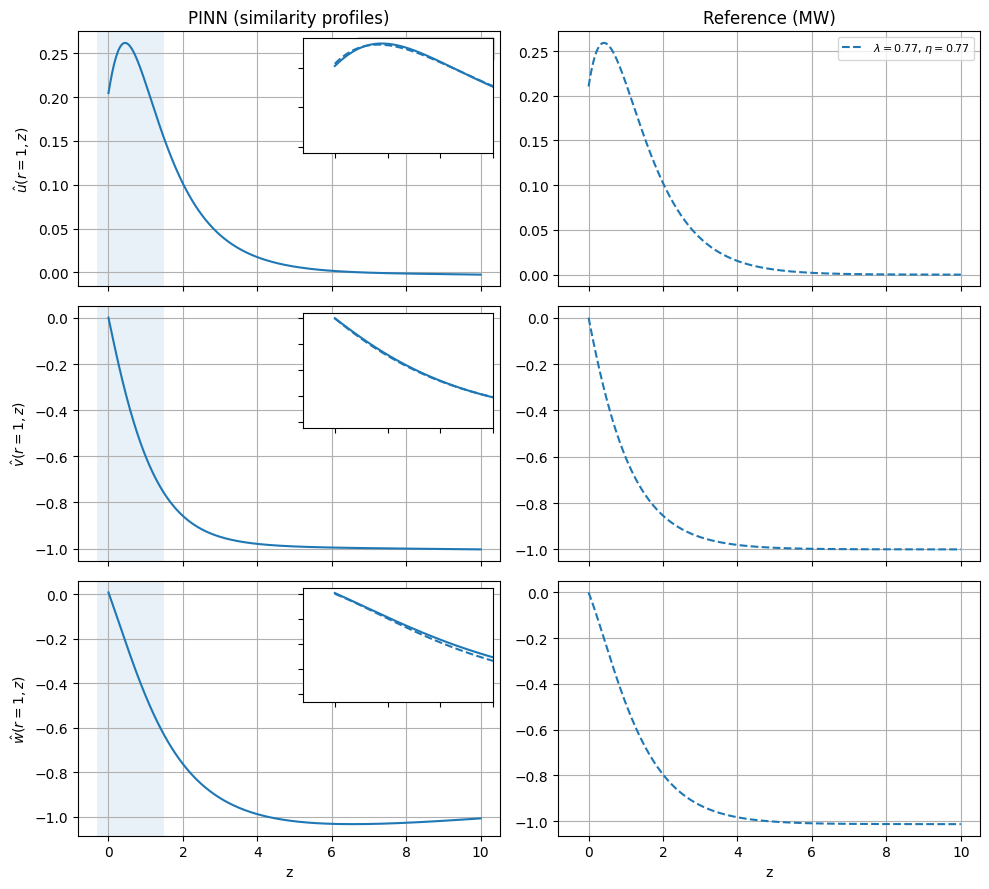

Figür kaydedildi: MWDisk_noise_sweep\PINN_vs_Ref_similarity_F_Gm1_H_r1.0_all_lambda.png

--- Wall derivatives @ (r=1, eta=0) ---
Ref: fp0=F'(0), gp0=(G-1)'(0)  |  PINN: dU/dz, dV/dz and corresponding fp0,gp0
lambda=0.77, eta= 0.0:   |   E_U=1.89250e-02, E_V=3.42369e-03, E_W=2.08144e-02   |   fp0_ref=2.73133127e-01, gp0_ref=-8.37980536e-01   |   dU/dz_pinn=2.61854559e-01, dV/dz_pinn=-7.76450276e-01   |   Err_der_U=0.04129329948036221      |   Err_der_V=0.07342683629404044      |   Err_w_inf=0.005841889559001438


In [4]:
import os
# ⚠ DDE_BACKEND deepxde importundan ÖNCE
os.environ["DDE_BACKEND"] = "pytorch"

import glob
import re
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch_directml
import deepxde as dde
from scipy.integrate import solve_bvp
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


# -------------------------------------------------
# Parametreler
# -------------------------------------------------
device = torch_directml.device()
torch.set_default_device(device)
torch.set_default_dtype(torch.float32)

Re = 196.0
delta = Re ** (-0.5)

L = 10.0
r_eval = 1.0

lambda_values = [0.77]
eta_values = [0.0] 

neu = 64
l = 4
act = "tanh"

base_dir = "MWDisk_noise_sweep"
noise_pct = 0
prefer_iter = 5000

eta_max = 10.0
N_eta = 400

colors = ["C0", "C1", "C2", "C3", "C4"]

def load_checkpoint_into_net(net, ckpt_path: str, strict: bool = True):
    """
    DeepXDE FNN (PyTorch backend) için checkpoint yükleyici.

    Desteklediği kayıt formatları:
      1) state_dict doğrudan (OrderedDict)
      2) {"state_dict": ...} veya {"model_state_dict": ...} veya {"model": ...} gibi dict içinde
      3) Bazı trainer checkpoint formatları (anahtarları tarar)

    Not:
      - net: build_net_with_transforms() ile dönen dde.nn.FNN nesnesi
      - ckpt_path: .pt/.pth dosya yolu
    """
    if ckpt_path is None or (not os.path.isfile(ckpt_path)):
        raise FileNotFoundError(f"Checkpoint bulunamadı: {ckpt_path}")

    # Torch load (DirectML device üstünde olsan bile önce CPU'ya çekmek daha güvenli)
    obj = torch.load(ckpt_path, map_location="cpu")

    # 1) Eğer doğrudan state_dict ise
    if isinstance(obj, dict):
        # 2) İçeride state_dict anahtarları varsa onları yakala
        candidate_keys = ["state_dict", "model_state_dict", "model", "net", "network"]
        state = None

        # doğrudan parametre isimleri taşıyan dict mi?
        # (tipik olarak key'ler "layers.0.weight" gibi olur)
        if any(isinstance(k, str) and ("weight" in k or "bias" in k) for k in obj.keys()):
            state = obj
        else:
            for k in candidate_keys:
                if k in obj and isinstance(obj[k], dict):
                    state = obj[k]
                    break

        if state is None:
            # son çare: dict içindeki ilk dict'i dene
            for v in obj.values():
                if isinstance(v, dict) and any(("weight" in kk or "bias" in kk) for kk in v.keys() if isinstance(kk, str)):
                    state = v
                    break

        if state is None:
            raise ValueError(
                f"Checkpoint formatı tanınmadı: {ckpt_path}\n"
                f"Bulunan anahtarlar: {list(obj.keys())[:30]}"
            )

        # Bazı kayıtlarda 'module.' prefix olabilir (DataParallel)
        if any(k.startswith("module.") for k in state.keys()):
            state = {k.replace("module.", "", 1): v for k, v in state.items()}

        # DeepXDE net bir torch.nn.Module türevidir; state_dict yüklenebilir
        missing, unexpected = net.load_state_dict(state, strict=strict)

        # strict=True iken zaten exception atar; strict=False ise raporlamak faydalı
        if (not strict) and (missing or unexpected):
            print(f"[CKPT] missing keys: {missing}")
            print(f"[CKPT] unexpected keys: {unexpected}")

        # Yükledikten sonra ağı yeniden device'a al
        net.to(device)
        return

    raise ValueError(f"Checkpoint objesi dict değil: {type(obj)} ({ckpt_path})")



# =================================================
# 1) MW-von Kármán nümerik çözücü (referans)
# =================================================
def vkd_ode(eta, y):
    f, fp, g, gp, h = y
    return np.vstack([
        fp,
        fp * h + f**2 - g**2,
        gp,
        gp * h + 2 * f * g,
        -2 * f,
    ])

def make_vkd_bc(lambda_slip=0.0, eta_slip=0.0, s_suction=0.0):
    def vkd_bc(ya, yb):
        f0, fp0, g0, gp0, h0 = ya
        fL, fpL, gL, gpL, hL = yb
        return np.array([
            f0 - lambda_slip * fp0,
            g0 - 1.0 - eta_slip * gp0,
            h0 + 2.0 * s_suction,
            fL,
            gL,
        ])
    return vkd_bc

def solve_vkd(lambda_slip, eta_slip, s_suction=0.0, eta_max=10.0, n_eta=800, tol=1e-10, max_nodes=200000):
    eta_mesh = np.linspace(0.0, eta_max, n_eta)
    y_guess = np.zeros((5, eta_mesh.size))
    y_guess[2, :] = 1.0
    y_guess[4, :] = -2.0 * s_suction

    bc = make_vkd_bc(lambda_slip=lambda_slip, eta_slip=eta_slip, s_suction=s_suction)
    sol = solve_bvp(vkd_ode, bc, eta_mesh, y_guess, tol=tol, max_nodes=max_nodes)

    if not sol.success:
        raise RuntimeError(f"VKD solver did not converge for λ={lambda_slip}, η={eta_slip}: {sol.message}")
    return sol


# =================================================
# 2) Network (checkpoint ile bire bir uyumlu)
#    feature_transform: (r,z)->(r,eta=z/delta)
#    output_transform : (..)->(U,V,W,P) fiziksel
# =================================================
def build_net_with_transforms(Re_local: float):
    delta_local = Re_local ** (-0.5)

    layers = [2] + [neu] * l + [4]
    net = dde.nn.FNN(layers, act, "Glorot uniform")

    def feature_transform(x):
        r = x[:, 0:1]
        z = x[:, 1:2]
        eta = z / delta_local
        return torch.cat([r, eta], dim=1)

    def output_transform(x, y):
        r = x[:, 0:1]
        U = r * y[:, 0:1]
        V = r * y[:, 1:2]
        W = delta_local * y[:, 2:3]       # fiziksel W = delta * H
        P = (delta_local ** 2) * y[:, 3:4]
        return torch.cat([U, V, W, P], dim=1)

    net.apply_feature_transform(feature_transform)
    net.apply_output_transform(output_transform)
    net.to(device)
    return net


# =================================================
# 3) Checkpoint bul/yükle
#    Klasör formatı: Re196_lam{lam}_eta{eta}_{neu}x{l}_noise0pct
# =================================================
def _iter_from_name(path: str) -> int:
    b = os.path.basename(path)
    m = re.search(r"-(\d+)\.(pt|pth)$", b)
    return int(m.group(1)) if m else -1

def find_any_ckpts(base_dir: str):
    patterns = [
        os.path.join(base_dir, "**", "model_adam-*.pt"),
        os.path.join(base_dir, "**", "model_adam-*.pth"),
        os.path.join(base_dir, "**", "model-*.pt"),
        os.path.join(base_dir, "**", "model-*.pth"),
    ]
    ckpts = []
    for pat in patterns:
        ckpts += glob.glob(pat, recursive=True)
    return sorted(set(ckpts))

def find_run_dir_and_ckpt_mw(
    base_dir: str,
    Re: float,
    lam: float,
    eta: float,
    neu: int,
    l: int,
    noise_pct: int = 0,
    prefer_iter: int = 5000,
    lam_tol: float = 1e-9,
    eta_tol: float = 1e-9,
):
    ckpts = find_any_ckpts(base_dir)
    if not ckpts:
        return None, None

    Re_i = int(Re)
    lam_t = float(lam)
    eta_t = float(eta)
    neu_i = int(neu)
    l_i   = int(l)
    noise_i = int(noise_pct)

    # run_dir adı ör: Re196_lam0.23_eta0.0_64x4_noise0pct
    run_re = re.compile(
        r"Re(?P<Re>\d+)_lam(?P<lam>[0-9]*\.?[0-9]+)_eta(?P<eta>[0-9]*\.?[0-9]+)_(?P<neu>\d+)x(?P<l>\d+)_noise(?P<noise>\d+)pct"
    )

    candidates = []  # (run_dir, ckpt_path)
    for ckpt in ckpts:
        run_dir = os.path.dirname(ckpt)
        dname = os.path.basename(run_dir)

        m = run_re.search(dname)
        if not m:
            continue

        Re_d   = int(m.group("Re"))
        lam_d  = float(m.group("lam"))
        eta_d  = float(m.group("eta"))
        neu_d  = int(m.group("neu"))
        l_d    = int(m.group("l"))
        noise_d= int(m.group("noise"))

        if Re_d != Re_i:
            continue
        if neu_d != neu_i or l_d != l_i:
            continue
        if noise_d != noise_i:
            continue
        if abs(lam_d - lam_t) > lam_tol:
            continue
        if abs(eta_d - eta_t) > eta_tol:
            continue

        candidates.append((run_dir, ckpt))

    if not candidates:
        return None, None

    # Aynı run_dir için ckpt seç
    run_dir = sorted(set([rd for rd, _ in candidates]))[0]
    ckpts_in_dir = sorted(
        glob.glob(os.path.join(run_dir, "*.pt")) + glob.glob(os.path.join(run_dir, "*.pth")),
        key=_iter_from_name
    )
    if not ckpts_in_dir:
        return run_dir, None

    # prefer_iter varsa
    pref_list = [
        os.path.join(run_dir, f"model_adam-{prefer_iter}.pt"),
        os.path.join(run_dir, f"model_adam-{prefer_iter}.pth"),
        os.path.join(run_dir, f"model-{prefer_iter}.pt"),
        os.path.join(run_dir, f"model-{prefer_iter}.pth"),
    ]
    for pref in pref_list:
        if os.path.isfile(pref):
            return run_dir, pref

    return run_dir, ckpts_in_dir[-1]

# =================================================
# 4) Hata metriği (relative L2)
# =================================================
def relative_L2_error(pred: np.ndarray, ref: np.ndarray) -> float:
    pred = np.asarray(pred).reshape(-1)
    ref  = np.asarray(ref).reshape(-1)
    num = np.sqrt(np.sum((pred - ref) ** 2))
    den = np.sqrt(np.sum(ref ** 2)) + 1e-16
    return float(num / den)

# =================================================
# 5) Dense karşılaştırma: fiziksel ağ çıktısından similarity profili çıkar
# =================================================
def get_similarity_profiles_from_net_and_vk(net, vk_sol, Re, r_eval=1.0, eta_max=10.0, N=400):
    delta_Re = Re ** (-0.5)

    # η-grid
    eta_dense = np.linspace(0.0, eta_max, N).astype(np.float64)

    # fiziksel z = delta * eta
    z_dense = (delta_Re * eta_dense).reshape(-1, 1).astype(np.float32)
    r_dense = (r_eval * np.ones_like(z_dense)).astype(np.float32)
    X_dense = np.hstack([r_dense, z_dense]).astype(np.float32)

    # --- Net prediction: output_transform uygulanmış -> fiziksel [U,V,W,P]
    with torch.no_grad():
        x_t = torch.tensor(X_dense, dtype=torch.float32, device=device)
        y_t = net(x_t)
        Y = y_t.detach().cpu().numpy()

    U_phys = Y[:, 0:1]
    V_phys = Y[:, 1:2]
    W_phys = Y[:, 2:3]/delta_Re  # fiziksel W = delta*H

    # similarity ölçeğine geri dön:
    # F = U/r, (G-1)=V/r, H=W/delta
    F_net   = U_phys *float(r_eval)
    Gm1_net = V_phys *float(r_eval)
    H_net   = W_phys 

    # --- Referans: VK solution aynı eta_dense üzerinde
    Y_vk = vk_sol.sol(eta_dense)  # (5,N)
    F_ref   = Y_vk[0, :].reshape(-1, 1).astype(np.float32)
    Gm1_ref = (Y_vk[2, :] - 1.0).reshape(-1, 1).astype(np.float32)
    H_ref   = Y_vk[4, :].reshape(-1, 1).astype(np.float32)

    # Hatalar
    E_F   = relative_L2_error(F_net,   F_ref)
    E_Gm1 = relative_L2_error(Gm1_net, Gm1_ref)
    E_H   = relative_L2_error(H_net,   H_ref)
    E_comb = relative_L2_error(
        np.hstack([F_net, Gm1_net, H_net]),
        np.hstack([F_ref, Gm1_ref, H_ref]),
    )

    w_pinn_inf = float(W_phys[-1, 0])                       # fiziksel W(z_max)
    w_ref_inf  = float((H_ref[-1, 0]))           # fiziksel W_ref(z_max)
    Err_w_inf  = abs(w_pinn_inf - w_ref_inf) / (abs(w_ref_inf) + 1e-16)

    # ============================
    # (NEW) Duvar türevleri (eta=0, r=r_eval)
    #   Ref:  fp(0), gp(0)  (VK çözümünden)
    #   PINN: dU/dz, dV/dz @ (r, z=0) ve buna karşılık fp, gp
    #   İlişki: U=rF(eta) => delta*dU/dz = r*F'(eta) => F'(0)= (delta*dU/dz)/r
    # ============================

    # --- Referans (VK) türevleri ---
    y0_vk = vk_sol.sol(0.0)   # [f, fp, g, gp, h] @ eta=0
    fp0_ref = float(y0_vk[1]) # F'(0)
    gp0_ref = float(y0_vk[3]) # g'(0) = (G-1)'(0)
    

    # --- PINN türevleri (autograd) ---
    x0 = torch.tensor([[float(r_eval), 0.0]], dtype=torch.float32, device=device, requires_grad=True)
    y0 = net(x0)  # fiziksel [U,V,W,P]

    U0 = y0[:, 0:1]*delta_Re
    V0 = y0[:, 1:2]*delta_Re

    dU_dx = torch.autograd.grad(
        outputs=U0, inputs=x0,
        grad_outputs=torch.ones_like(U0),
        retain_graph=True, create_graph=False
    )[0]
    dV_dx = torch.autograd.grad(
        outputs=V0, inputs=x0,
        grad_outputs=torch.ones_like(V0),
        retain_graph=False, create_graph=False
    )[0]

    dU_dz_pinn = float(dU_dx[0, 1].detach().cpu().item())
    dV_dz_pinn = float(dV_dx[0, 1].detach().cpu().item())

    # similarity türevleri (eta-türevi): fp = F'(0), gp = (G-1)'(0)
    fp0_pinn = float(dU_dz_pinn)
    gp0_pinn = float(dV_dz_pinn)

    Err_der_U = abs(fp0_pinn - fp0_ref) / (abs(fp0_ref) if abs(fp0_ref) > 0 else np.nan)
    Err_der_V = abs(gp0_pinn - gp0_ref) / (abs(gp0_ref) if abs(gp0_ref) > 0 else np.nan)



    derivs = (fp0_ref, gp0_ref, dU_dz_pinn, dV_dz_pinn, fp0_pinn, gp0_pinn, Err_der_U, Err_der_V, Err_w_inf)

    return eta_dense, z_dense, F_net, Gm1_net, H_net, F_ref, Gm1_ref, H_ref, E_F, E_Gm1, E_H, derivs


# =================================================
# 6) Tüm λ için yükle + profil üret
# =================================================
F_all, Gm1_all, H_all = {}, {}, {}
F_ref_all, Gm1_ref_all, H_ref_all = {}, {}, {}
F_ref_all_eta, Gm1_ref_all_eta, H_ref_all_eta = {}, {}, {}
err_all = {}
deriv_all = {}
F_all_eta, Gm1_all_eta, H_all_eta = {}, {}, {}
F_all_lam_eta, Gm1_all_lam_eta, H_all_lam_eta = {}, {}, {}
F_ref_all_lam_eta, Gm1_ref_all_lam_eta, H_ref_all_lam_eta = {}, {}, {} 

for lam in lambda_values:
    for eta in eta_values:
        

        run_dir, ckpt_path = find_run_dir_and_ckpt_mw(
            base_dir=base_dir, Re=Re, lam=lam, eta=eta,
            neu=neu, l=l, noise_pct=noise_pct, prefer_iter=prefer_iter
        )

        if run_dir is None or ckpt_path is None:
            print(f"[UYARI] ckpt yok: Re={Re}, lam={lam}, eta={eta}")
            continue

        print(f"λ={lam}, η={eta} -> {ckpt_path}")

        net = build_net_with_transforms(Re_local=Re)
        load_checkpoint_into_net(net, ckpt_path)
        net.eval()

        vk_sol = solve_vkd(lambda_slip=lam, eta_slip=eta, eta_max=eta_max, n_eta=800)

        eta_dense, z_dense, F_net, Gm1_net, H_net, F_ref, Gm1_ref, H_ref, E_f, E_Gm1, E_h, derivs = \
            get_similarity_profiles_from_net_and_vk(net, vk_sol, Re, r_eval=r_eval, eta_max=eta_max, N=N_eta)
        errs = [E_f, E_Gm1, E_h]
        deriv_all[(lam, eta)] = (derivs, E_f, E_Gm1, E_h)

        # plot x-axis: fiziksel z
        z_plot = z_dense[:, 0].copy()

        F_all[lam] = F_net[:, 0]
        F_all_eta[eta] = F_net[:, 0]
        F_all_lam_eta[lam] = F_net[:, 0]
        Gm1_all[lam] = Gm1_net[:, 0]
        Gm1_all_eta[eta] = Gm1_net[:, 0]
        Gm1_all_lam_eta[lam] = Gm1_net[:, 0]
        H_all[lam] = H_net[:, 0]
        H_all_eta[eta] = H_net[:, 0]
        H_all_lam_eta[lam] = H_net[:, 0]


        F_ref_all[lam] = F_ref[:, 0]
        F_ref_all_eta[eta] = F_ref[:, 0]
        F_ref_all_lam_eta[lam] = F_ref[:, 0]
        Gm1_ref_all[lam] = Gm1_ref[:, 0]
        Gm1_ref_all_eta[eta] = Gm1_ref[:, 0]
        Gm1_ref_all_lam_eta[lam] = Gm1_ref[:, 0]
        H_ref_all[lam] = H_ref[:, 0]
        H_ref_all_eta[eta] = H_ref[:, 0]
        H_ref_all_lam_eta[lam] = H_ref[:, 0]


        err_all[lam] = errs  # (E_F,E_Gm1,E_H,E_comb)


# =================================================
# 7) Grafik: (F, G-1, H) x (PINN, Ref) + zoom inset
# =================================================
fig, axes = plt.subplots(3, 2, figsize=(10, 9), sharex=True)

# zoom aralığı (z uzayında)
z0, z1 = -0.3, 1.5
mask = (z_plot >= z0) & (z_plot <= z1)

# --- F ---
for lam, c in zip(lambda_values, colors):
    label = rf"$\lambda={lam}$, $\eta={lam}$"
    axes[0, 0].plot(eta_dense, F_all_lam_eta[lam], color=c, label=label)
    axes[0, 1].plot(eta_dense, F_ref_all_lam_eta[lam], color=c, linestyle="--", label=label)
axes[0, 0].set_ylabel(r"$\hat{u}(r=1,z)$")
axes[0, 0].set_title("PINN (similarity profiles)")
axes[0, 1].set_title("Reference (MW)")

# --- G-1 ---
for lam, c in zip(lambda_values, colors):
    if lam not in Gm1_all_lam_eta:
        continue
    label = rf"$\lambda={lam}$, $\eta={lam}$"
    axes[1, 0].plot(eta_dense, Gm1_all_lam_eta[lam], color=c, label=label)
    axes[1, 1].plot(eta_dense, Gm1_ref_all_lam_eta[lam], color=c, linestyle="--", label=label)
axes[1, 0].set_ylabel(r"$\hat{v}(r=1,z)$")

# --- H ---
for lam, c in zip(lambda_values, colors):
    if lam not in H_all_lam_eta:
        continue
    label = rf"$\lambda={lam}$, $\eta={lam}$"
    axes[2, 0].plot(eta_dense, H_all_lam_eta[lam], color=c, label=label)
    axes[2, 1].plot(eta_dense, H_ref_all_lam_eta[lam], color=c, linestyle="--", label=label)
axes[2, 0].set_ylabel(r"$\hat{w}(r=1,z)$")
axes[2, 0].set_xlabel("z")
axes[2, 1].set_xlabel("z")

# grid + legend
for i in range(3):
    for j in range(2):
        axes[i, j].grid(True)

axes[0, 0].legend(loc="best", fontsize=8)
axes[0, 1].legend(loc="best", fontsize=8)

# inset’ler (soldaki sütun)
def add_inset(ax_main, y_dict, yref_dict):
    ax_main.axvspan(z0, z1, alpha=0.1)
    ax_in = inset_axes(ax_main, width="45%", height="45%", loc="upper right")
    ax_in.set_xticklabels([])
    ax_in.set_yticklabels([])
    for lam, c in zip(lambda_values, colors):
        for eta, c in zip(lambda_values, colors):    
            ax_in.plot(eta_dense[mask], y_dict[lam][mask], color=c)
            ax_in.plot(eta_dense[mask], yref_dict[lam][mask], color=c, linestyle="--")
        ax_in.set_xlim(z0, z1)
        ax_in.tick_params(labelsize=7)

add_inset(axes[0, 0], F_all_lam_eta, F_ref_all_lam_eta)
add_inset(axes[1, 0], Gm1_all_lam_eta, Gm1_ref_all_lam_eta)
add_inset(axes[2, 0], H_all_lam_eta, H_ref_all_lam_eta)

plt.tight_layout()
out_png = os.path.join(base_dir, f"PINN_vs_Ref_similarity_F_Gm1_H_r{r_eval}_all_lambda.png")
out_pdf = os.path.join(base_dir, f"PINN_vs_Ref_similarity_F_Gm1_H_r{r_eval}_all_lambda.pdf")
plt.savefig(out_png, dpi=200)
plt.savefig(out_pdf, dpi=200)
plt.show()

print("Figür kaydedildi:", out_png)


print("\n--- Wall derivatives @ (r=1, eta=0) ---")
print("Ref: fp0=F'(0), gp0=(G-1)'(0)  |  PINN: dU/dz, dV/dz and corresponding fp0,gp0")

for lam in lambda_values:
    for eta in eta_values:
        key = (lam, eta)
        if key not in deriv_all:
            print(f"lambda={lam:>4}, eta={eta:>4}: [YOK] (ckpt bulunamadı / yüklenmedi)")
            continue
        derivs, E_f, E_Gm1, E_h = deriv_all[key]
        fp0_ref, gp0_ref, dU_dz_pinn, dV_dz_pinn, fp0_pinn, gp0_pinn, Err_der_U, Err_der_V, Err_w_inf = derivs

        print(
            f"lambda={lam:>4}, eta={eta:>4}:   |   "
            f"E_U={E_f:.5e}, E_V={E_Gm1:.5e}, E_W={E_h:.5e}   |   "
            f"fp0_ref={fp0_ref:.8e}, gp0_ref={gp0_ref:.8e}   |   "
            f"dU/dz_pinn={dU_dz_pinn:.8e}, dV/dz_pinn={dV_dz_pinn:.8e}   |   "    
            f"Err_der_U={Err_der_U}      |   "       
            f"Err_der_V={Err_der_V}      |   "
            f"Err_w_inf={Err_w_inf}"
        )
